In [35]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [36]:
import torch
import torch.nn as nn
import torch.optim as optim


import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import os
import itertools
import cupy as cp

In [37]:

from src.metrics import Metrics

In [38]:
SEED = 42

In [39]:
X_images = cp.load("data/X_images.npy")
y_images = cp.load("data/y_images.npy")

from src.data_splitting import split_data

X_dev, y_dev, X_test, y_test = split_data(X_images, y_images, ratio=0.2, seed=SEED)
X_train, y_train, X_val, y_val = split_data(X_dev, y_dev, ratio=0.2, seed=SEED)


X_train = X_train.astype(cp.float32) / 255.0
X_val   = X_val.astype(cp.float32)   / 255.0
X_test  = X_test.astype(cp.float32)  / 255.0
X_dev   = X_dev.astype(cp.float32)   / 255.0


In [40]:

# ----------------------------
# Datos y parámetros globales
# ----------------------------
input_size = X_train.shape[1]
n_classes  = int(cp.max(y_train)) + 1


batch_size  = 64
lr          = 0.005
l2_lambda   = 0.0005
dropout_p   = 0.3
use_bn      = False
early_stop  = False
patience    = 0
lr_sched    = 'exp'    # 'none'|'linear'|'exp'

# agregué:
decay_rate = 0.85
lr_min      = 0.01

arch = [input_size, 512, 256, n_classes]

epochs_M2   = 400
epochs_M3   = 200       # menor para exploración


# ----------------------------
# Auxiliares
# ----------------------------
def get_dataloader(X, y, batch_size):
    X_t = torch.tensor(cp.asnumpy(X), dtype=torch.float32)
    y_t = torch.tensor(cp.asnumpy(y), dtype=torch.long)
    ds  = torch.utils.data.TensorDataset(X_t, y_t)
    return torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=True)

def build_scheduler(optimizer, conf, n_batches):
    sched = conf['lr_schedule']
    if sched == 'linear':
        # end_factor hace que lr pase de initial_lr a lr_min
        end_factor = conf['lr_min'] / conf['learning_rate']
        total_iters = conf['patience'] * n_batches if conf['patience']>0 else conf['epochs'] * n_batches
        return optim.lr_scheduler.LinearLR(
            optimizer,
            start_factor=1.0,
            end_factor=end_factor,
            total_iters=total_iters
        )
    if sched == 'exp':
        # decay_rate es tu gamma
        return optim.lr_scheduler.ExponentialLR(optimizer,
                                                gamma=conf['decay_rate'])
    return None

def train_model(ModelClass, conf, epochs):
    train_dl = get_dataloader(X_train, y_train, conf['batch_size'])
    val_dl   = get_dataloader(X_val,   y_val,   conf['batch_size'])

    model     = ModelClass(conf)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(),
                           lr=conf['learning_rate'],
                           weight_decay=conf['l2_lambda'])
    # ahora pasamos todo el conf
    scheduler = build_scheduler(optimizer, conf, len(train_dl))

    best_val_loss = float('inf')
    patience_ctr  = 0
    best_state    = None

    for epoch in range(1, epochs + 1):
        model.train()
        for Xb, yb in train_dl:
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            optimizer.step()
            if scheduler:
                scheduler.step()

        model.eval()
        val_loss = 0.0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for Xb, yb in val_dl:
                logits = model(Xb)
                l = criterion(logits, yb)
                val_loss += l.item() * Xb.size(0)
                preds = logits.argmax(dim=1)
                all_preds.append(cp.array(preds.cpu().numpy()))
                all_labels.append(cp.array(yb.cpu().numpy()))

        val_loss /= len(val_dl.dataset)
        y_true = cp.concatenate(all_labels)
        y_pred = cp.concatenate(all_preds)
        m = Metrics(y_true, y_pred)
        acc = m.accuracy()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_ctr  = 0
            best_state    = model.state_dict()
        else:
            patience_ctr += 1
            if conf['early_stopping'] and patience_ctr >= conf['patience']:
                break

    model.load_state_dict(best_state)
    return model



>>> Entrenando M2...
### M2: Métricas finales


### Desempeño M2
**Accuracy:** **0.1650**  
**Cross-Entropy Loss:** 3.5367  


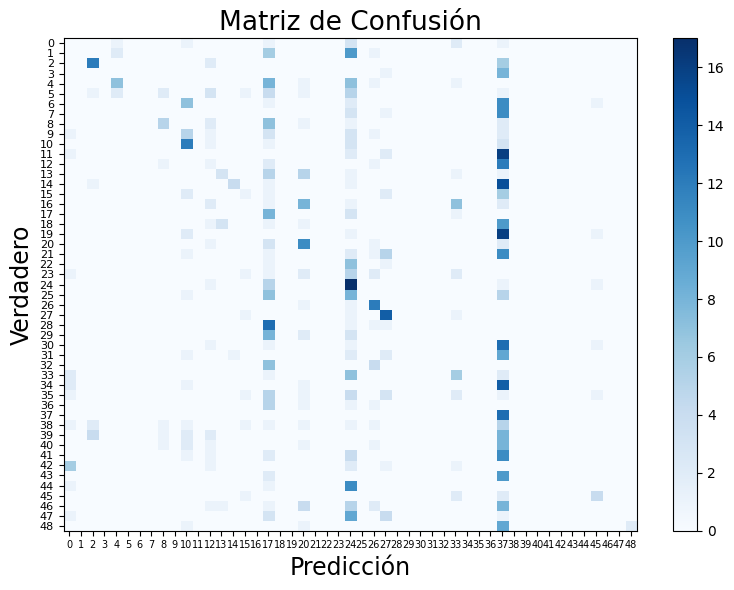

In [42]:

# ----------------------------
# 1) Entrena y evalúa M2
# ----------------------------
class MLP_M2(nn.Module):
    def __init__(self, conf):
        super().__init__()
        layers = []
        sizes  = conf['arch']
        for i in range(len(sizes) - 1):
            layers.append(nn.Linear(sizes[i], sizes[i+1]))
            if i < len(sizes) - 2:
                if conf['use_batchnorm']:
                    layers.append(nn.BatchNorm1d(sizes[i+1]))
                layers.append(nn.ReLU())
                if conf['dropout_p'] > 0:
                    layers.append(nn.Dropout(conf['dropout_p']))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

conf_M2 = {
    'arch':          [input_size, 512, 256, n_classes],
    'optimizer':     'adam',
    'batch_size':    batch_size,
    'learning_rate': lr,
    'l2_lambda':     l2_lambda,
    'dropout_p':     dropout_p,
    'use_batchnorm': use_bn,
    'early_stopping': early_stop,
    'patience':       patience,
    'lr_schedule':    lr_sched,
    'decay_rate':     decay_rate,
    'lr_min':         lr_min,
}

print(">>> Entrenando M2...")
M2 = train_model(MLP_M2, conf_M2, epochs_M2)

# Evaluación final de M2
with torch.no_grad():
    Xv_t = torch.tensor(cp.asnumpy(X_val), dtype=torch.float32)
    logits = M2(Xv_t)
    probs  = torch.softmax(logits, dim=1)
    preds  = probs.argmax(dim=1)

y_true = y_val
y_pred = cp.array(preds.cpu().numpy())
y_proba= cp.array(probs.cpu().numpy())

print("### M2: Métricas finales")
m2_metrics = Metrics(y_true, y_pred, y_proba)
m2_metrics.report_metrics(title="Desempeño M2")


In [ ]:

# ----------------------------
# 2) Explora arquitecturas para M3
# ----------------------------
architectures = [
    [input_size, 32,        n_classes],
    [input_size, 64,        n_classes],
    [input_size, 64, 32,    n_classes],
    [input_size, 100,       n_classes],
    [input_size, 128, 64,   n_classes],
    [input_size, 100, 50,   n_classes],
    [input_size, 64, 64, 32,n_classes],
    [input_size, 150, 80,   n_classes],
    [input_size, 128, 64,32,n_classes],
    [input_size, 256,128,64,n_classes],
    [input_size, 100,50,25, n_classes],
    [input_size,128,128,64,32,n_classes],
    [input_size,256,       n_classes],
    [input_size,512,       n_classes],
    [input_size,200,100,50,           n_classes],
    [input_size,256,128,64,32,        n_classes],
    [input_size,64,64,64,64,           n_classes],
    [input_size,128,128,128,           n_classes],
    [input_size,128,32,                n_classes],
    [input_size,64,16,                 n_classes],
    [input_size,256,128,64,32,16,      n_classes],
    [input_size,128,128,64,64,32,      n_classes],
    [input_size,64,128,64,              n_classes],
    [input_size,32,64,128,64,32,        n_classes],
]

class MLP_M3(nn.Module):
    def __init__(self, conf):
        super().__init__()
        layers = []
        sizes  = conf['arch']
        for i in range(len(sizes) - 1):
            layers.append(nn.Linear(sizes[i], sizes[i+1]))
            if i < len(sizes) - 2:
                if conf['use_batchnorm']:
                    layers.append(nn.BatchNorm1d(sizes[i+1]))
                layers.append(nn.ReLU())
                if conf['dropout_p'] > 0:
                    layers.append(nn.Dropout(conf['dropout_p']))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

best_acc = -1.0
best_arch = None
best_model= None

print("\n>>> Explorando arquitecturas para M3...")
for arch in architectures:
    conf = conf_M2.copy()
    conf['arch'] = arch
    model = train_model(MLP_M3, conf, epochs_M3)

    # Evalúa una sola pasada para medir accuracy
    with torch.no_grad():
        Xv_t = torch.tensor(cp.asnumpy(X_val), dtype=torch.float32)
        logits = model(Xv_t)
        preds  = logits.argmax(dim=1)
    acc = float((preds.cpu().numpy() == cp.asnumpy(y_val)).mean())

    print(f"  {arch} -> Acc={acc:.4f}")
    if acc > best_acc:
        best_acc  = acc
        best_arch = arch
        best_model= model

print(f"\n>> Mejor M3: {best_arch} con Acc={best_acc:.4f}")

# Evaluación final de M3
with torch.no_grad():
    Xv_t = torch.tensor(cp.asnumpy(X_val), dtype=torch.float32)
    logits = best_model(Xv_t)
    probs  = torch.softmax(logits, dim=1)
    preds  = probs.argmax(dim=1)

y_pred_m3 = cp.array(preds.cpu().numpy())
y_proba_m3= cp.array(probs.cpu().numpy())
y_true    = y_val

print("### M3: Métricas finales")
m3_metrics = Metrics(y_true, y_pred_m3, y_proba_m3)
m3_metrics.report_metrics(title="Desempeño M3")



>> Arquitectura M4 elegida: (784, 2048, 2048, 2048, 49)
   train_loss=0.2144, val_loss=22.2446

### M4: Métricas finales


### Desempeño M4 (Over‑fitting)
**Accuracy:** **0.5400**  
**Cross-Entropy Loss:** 11.0634  


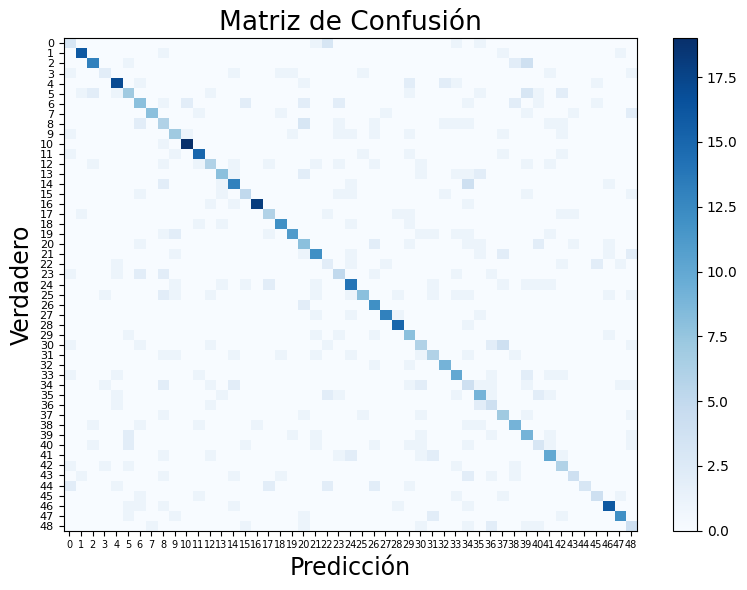

In [10]:
# ----------------------------
# 3) Búsqueda de M4 (over‑fitting)
# ----------------------------
overfit_archs = [
    # Muy profundas y amplias
    [input_size, 2048, 1024, 512, 256, 128, n_classes],
    [input_size, 1024, 1024, 1024, 512, 512, 256, 128, n_classes],
    [input_size, 4096, 2048, 1024, 512, 256, 128, 64, n_classes],
    
    # Muchas capas con “embudo” progresivo
    [input_size, 1024, 512, 256, 128, 64, 32, 16, n_classes],
    [input_size, 2048, 1024, 512, 256, 128, 64, 32, 16, n_classes],
    
    # Anchura extrema en la primera capa
    [input_size, 8192, 4096, 2048, 1024, 512, n_classes],
    [input_size, 4096, 4096, 2048, 1024, 512, 256, n_classes],
    
    # Capas uniformes muy anchas
    [input_size, 2048, 2048, 2048, n_classes],
    [input_size, 1024, 1024, 1024, 1024, n_classes],
    
    # Back‑to‑back gigantes
    [input_size, 512, 512, 512, 512, 512, 512, n_classes],
    [input_size, 256, 512, 1024, 2048, 1024, 512, 256, n_classes],
]


conf_base_m4 = {
    'optimizer':     'gd',
    'batch_size':    batch_size,
    'learning_rate': lr,
    'l2_lambda':     0.0,
    'dropout_p':     0.0,
    'use_batchnorm': False,
    'early_stopping': False,
    'patience':       0,
    'lr_schedule':    'none',
}

m4_report = {}
for arch in overfit_archs:
    conf = dict(conf_base_m4, **{'arch': arch})
    # DataLoaders
    train_dl = get_dataloader(X_train, y_train, conf['batch_size'])
    val_dl   = get_dataloader(X_val,   y_val,   conf['batch_size'])

    model = MLP_M3(conf)  # reutiliza la clase genérica
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        model.parameters(),
        lr=conf['learning_rate'],
        weight_decay=conf['l2_lambda']
    )

    train_losses, val_losses = [], []
    for epoch in range(1, epochs_M3 + 1):
        # train
        model.train()
        running_train = 0.0
        for Xb, yb in train_dl:
            optimizer.zero_grad()
            logits = model(Xb)
            l = criterion(logits, yb)
            l.backward()
            optimizer.step()
            running_train += l.item() * Xb.size(0)
        train_losses.append(running_train / len(train_dl.dataset))

        # val
        model.eval()
        running_val = 0.0
        with torch.no_grad():
            for Xb, yb in val_dl:
                logits = model(Xb)
                l = criterion(logits, yb)
                running_val += l.item() * Xb.size(0)
        val_losses.append(running_val / len(val_dl.dataset))

    m4_report[tuple(arch)] = {
        'model':        model,
        'train_loss':   train_losses[-1],
        'val_loss':     val_losses[-1],
        'train_curve':  train_losses,
        'val_curve':    val_losses
    }

# Selección M4 por mayor gap val_loss - train_loss
best_arch, stats = max(
    m4_report.items(),
    key=lambda kv: (kv[1]['val_loss'] - kv[1]['train_loss'])
)
best_model_m4 = stats['model']
print(f"\n>> Arquitectura M4 elegida: {best_arch}")
print(f"   train_loss={stats['train_loss']:.4f}, val_loss={stats['val_loss']:.4f}")

# ----------------------------
# 4) Evaluación final de M4 con Metrics
# ----------------------------
best_model_m4.eval()
with torch.no_grad():
    Xv_t = torch.tensor(cp.asnumpy(X_val), dtype=torch.float32)
    logits = best_model_m4(Xv_t)
    probs  = torch.softmax(logits, dim=1)
    preds  = probs.argmax(dim=1)

y_true_m4  = y_val
y_pred_m4  = cp.array(preds.cpu().numpy())
y_proba_m4 = cp.array(probs.cpu().numpy())

print("\n### M4: Métricas finales")
m4_metrics = Metrics(y_true_m4, y_pred_m4, y_proba_m4)
m4_metrics.report_metrics(title="Desempeño M4 (Over‑fitting)")


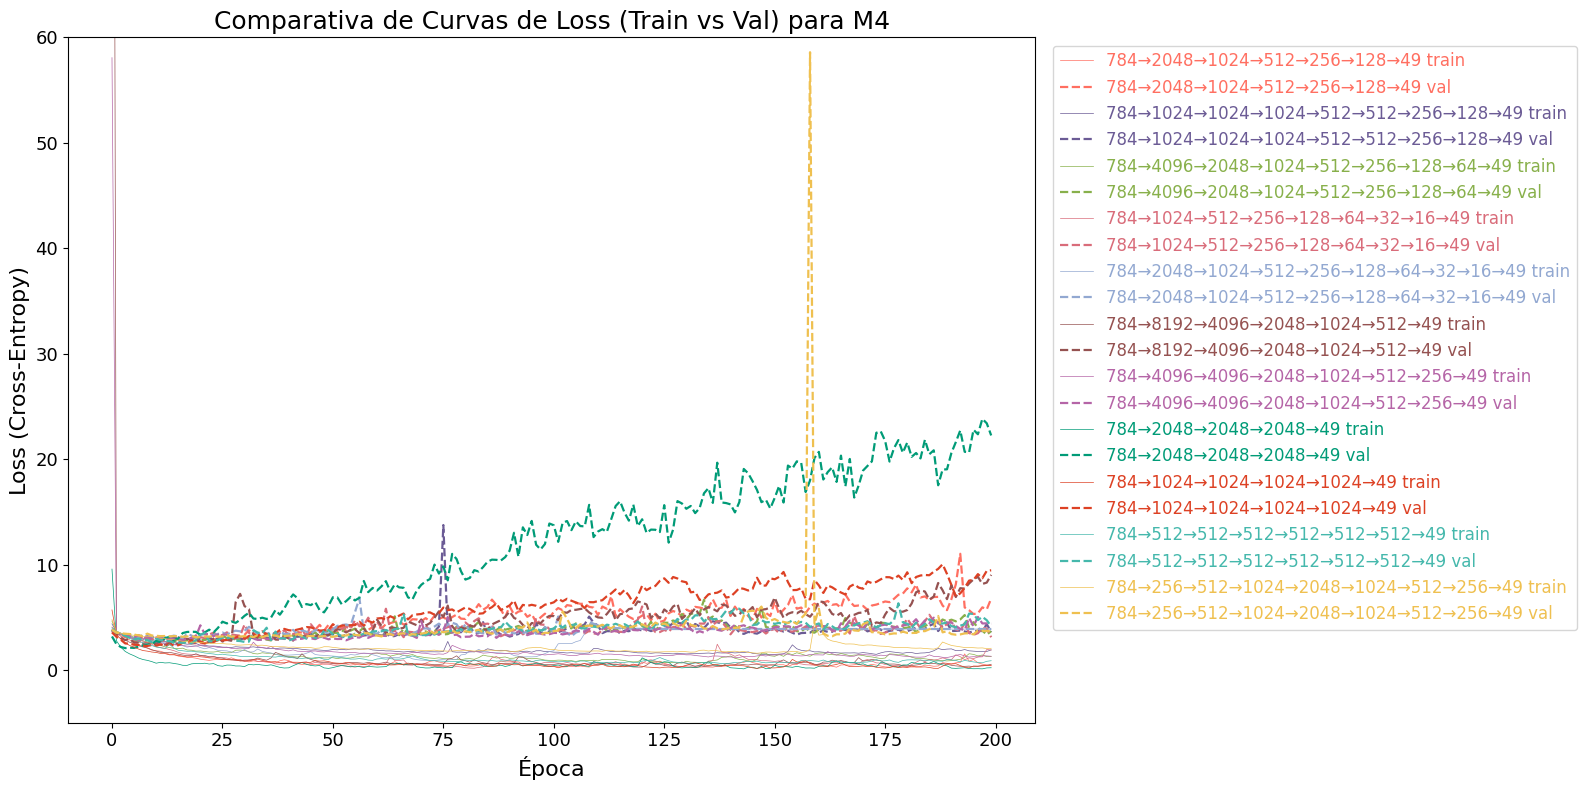

In [32]:
# --- 1) Preparamos el plot ---
plt.figure(figsize=(16, 8))

colors = ['#FF6F61', '#6B5B95', '#88B04B', '#D96C7A', '#92A8D1', 
          '#955251', '#B565A7', '#009B77', '#DD4124', '#45B8AC', 
          '#EFC050']

for i, (arch_tuple, stats) in enumerate(m4_report.items()):
    arch_label = "→".join(str(x) for x in arch_tuple)
    train_curve = stats['train_curve']
    val_curve   = stats['val_curve']
    
    color = colors[i % len(colors)]  # En caso de que haya más arquitecturas que colores
    plt.plot(train_curve, label=f"{arch_label} train", color=color, linewidth=0.5)
    plt.plot(val_curve, '--', label=f"{arch_label} val", color=color, linewidth=1.6)

plt.xlabel("Época", fontsize=16)
plt.ylabel("Loss (Cross-Entropy)", fontsize=16)
plt.title("Comparativa de Curvas de Loss (Train vs Val) para M4", fontsize=18)
plt.ylim(-5, 60)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

leg = plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=12)

# colorear cada texto de la leyenda según el color de su línea
for text, line in zip(leg.get_texts(), leg.get_lines()):
    text.set_color(line.get_color())

plt.tight_layout()
# --- 3) Mostrar plot ---
plt.show()

In [ ]:
# ----------------------------
# 3) Búsqueda de M4 (over‑fitting)
# ----------------------------
overfit_archs = [
    # Muy profundas y amplias
    [input_size, 2048, 1024, 512, 256, 128, n_classes],
    [input_size, 1024, 1024, 1024, 512, 512, 256, 128, n_classes],
    [input_size, 4096, 2048, 1024, 512, 256, 128, 64, n_classes],
    
    # Muchas capas con “embudo” progresivo
    [input_size, 1024, 512, 256, 128, 64, 32, 16, n_classes],
    [input_size, 2048, 1024, 512, 256, 128, 64, 32, 16, n_classes],
    
    # Anchura extrema en la primera capa
    [input_size, 8192, 4096, 2048, 1024, 512, n_classes],
    [input_size, 4096, 4096, 2048, 1024, 512, 256, n_classes],
    
    # Capas uniformes muy anchas
    [input_size, 2048, 2048, 2048, n_classes],
    [input_size, 1024, 1024, 1024, 1024, n_classes],
    
    # Back‑to‑back gigantes
    [input_size, 512, 512, 512, 512, 512, 512, n_classes],
    [input_size, 256, 512, 1024, 2048, 1024, 512, 256, n_classes],
]


conf_base_m4 = {
    'optimizer':     'gd',
    'batch_size':    batch_size,
    'learning_rate': lr,
    'l2_lambda':     0.0,
    'dropout_p':     0.0,
    'use_batchnorm': False,
    'early_stopping': False,
    'patience':       0,
    'lr_schedule':    'none',
}

m4_report = {}
for arch in overfit_archs:
    conf = dict(conf_base_m4, **{'arch': arch})
    # DataLoaders
    train_dl = get_dataloader(X_train, y_train, conf['batch_size'])
    val_dl   = get_dataloader(X_val,   y_val,   conf['batch_size'])

    model = MLP_M3(conf)  # reutiliza la clase genérica
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        model.parameters(),
        lr=conf['learning_rate'],
        weight_decay=conf['l2_lambda']
    )

    train_losses, val_losses = [], []
    for epoch in range(1, epochs_M3 + 1):
        # train
        model.train()
        running_train = 0.0
        for Xb, yb in train_dl:
            optimizer.zero_grad()
            logits = model(Xb)
            l = criterion(logits, yb)
            l.backward()
            optimizer.step()
            running_train += l.item() * Xb.size(0)
        train_losses.append(running_train / len(train_dl.dataset))

        # val
        model.eval()
        running_val = 0.0
        with torch.no_grad():
            for Xb, yb in val_dl:
                logits = model(Xb)
                l = criterion(logits, yb)
                running_val += l.item() * Xb.size(0)
        val_losses.append(running_val / len(val_dl.dataset))

    m4_report[tuple(arch)] = {
        'model':        model,
        'train_loss':   train_losses[-1],
        'val_loss':     val_losses[-1],
        'train_curve':  train_losses,
        'val_curve':    val_losses
    }

# Selección M4 por mayor gap val_loss - train_loss
best_arch, stats = max(
    m4_report.items(),
    key=lambda kv: (kv[1]['val_loss'] - kv[1]['train_loss'])
)
best_model_m4 = stats['model']
print(f"\n>> Arquitectura M4 elegida: {best_arch}")
print(f"   train_loss={stats['train_loss']:.4f}, val_loss={stats['val_loss']:.4f}")

# ----------------------------
# 4) Evaluación final de M4 con Metrics
# ----------------------------
best_model_m4.eval()
with torch.no_grad():
    Xv_t = torch.tensor(cp.asnumpy(X_val), dtype=torch.float32)
    logits = best_model_m4(Xv_t)
    probs  = torch.softmax(logits, dim=1)
    preds  = probs.argmax(dim=1)

y_true_m4  = y_val
y_pred_m4  = cp.array(preds.cpu().numpy())
y_proba_m4 = cp.array(probs.cpu().numpy())

print("\n### M4: Métricas finales")
m4_metrics = Metrics(y_true_m4, y_pred_m4, y_proba_m4)
m4_metrics.report_metrics(title="Desempeño M4 (Over‑fitting)")


In [36]:
import torch
import cupy as cp
import pandas as pd

# 1) Carga y normalización idéntica al entrenamiento
X_comp = cp.load('data/X_COMP.npy')     # shape (n_samples, n_features)
X_comp = X_comp / 255.0            # **normalización**

# 2) PyTorch tensor
X_comp_t = torch.tensor(cp.asnumpy(X_comp), dtype=torch.float32)

# 3) Modelo M3 ya entrenado (asegúrate de haber recargado best_model)
best_model.eval()

# 4) Inferencia
with torch.no_grad():
    logits = best_model(X_comp_t)
    probs  = torch.softmax(logits, dim=1)

# 5) A CuPy → pandas
probs_cp = cp.array(probs.cpu().numpy())
col_names = [f"Clase_{i}" for i in range(probs_cp.shape[1])]
df = pd.DataFrame(probs_cp.get(), columns=col_names)

# 6) Guardado
df.to_csv('Tissera_AnaPaula_predicciones.csv', index=False)
print("Generado Tissera_AnaPaula_predicciones.csv con normalización.")


Generado Tissera_AnaPaula_predicciones.csv con normalización.
